In [1]:
import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=12"

import sys
sys.path.append('../src/')

import numpy as onp
import jax
import jax.numpy as jnp

from myutils import Ntime, ACFs, set_detectors, load_tables
from myutils import ln_likelihood_full_jit, ln_likelihood_full
from myutils import patterns_for_params

from scipy.linalg import toeplitz
import scipy.signal as sig

import lal

jax.config.update("jax_enable_x64", True) #double precision

/Users/kallol/Work/skyRing/examples/../src/myutils.py:3: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


In [2]:
import corner
import matplotlib.lines as mlines

from matplotlib.ticker import MaxNLocator
from matplotlib.colors import to_rgba
from scipy.ndimage import gaussian_filter

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from chainconsumer import Chain, ChainConsumer, Truth, ChainConfig, PlotConfig

import numpyro
from numpyro.contrib.nested_sampling import NestedSampler
import numpyro.distributions as dist
numpyro.enable_x64()

/Users/kallol/miniconda3/envs/skyloc_ringdown/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
M_obs      = 72 
chi_obs    = 0.75 
A220_obs   = 0.5
P220_obs   = 2.2 
A221_obs   = 0.8 
P221_obs   = 4.5 
ra         = 2.33
dec        = 0.19
psi        = 1.329
iota       = 0.65 


theta_GT = jnp.array([M_obs, chi_obs, A220_obs, P220_obs, A221_obs, P221_obs, onp.cos(iota), ra, onp.sin(dec), psi])


# Load the posterior samples (get posterior files from the zenodo repo)

In [5]:
posterior_full_sky  = onp.load('./posterior_files/simulations_220_221/posterior.noiseless-sim.full-sky.npy')
posterior_fixed_sky_inj = onp.load('./posterior_files/simulations_220_221/posterior.noiseless-sim.fixed-sky.npy')

# Corner plots comparing Full-sky and Fixed-sky

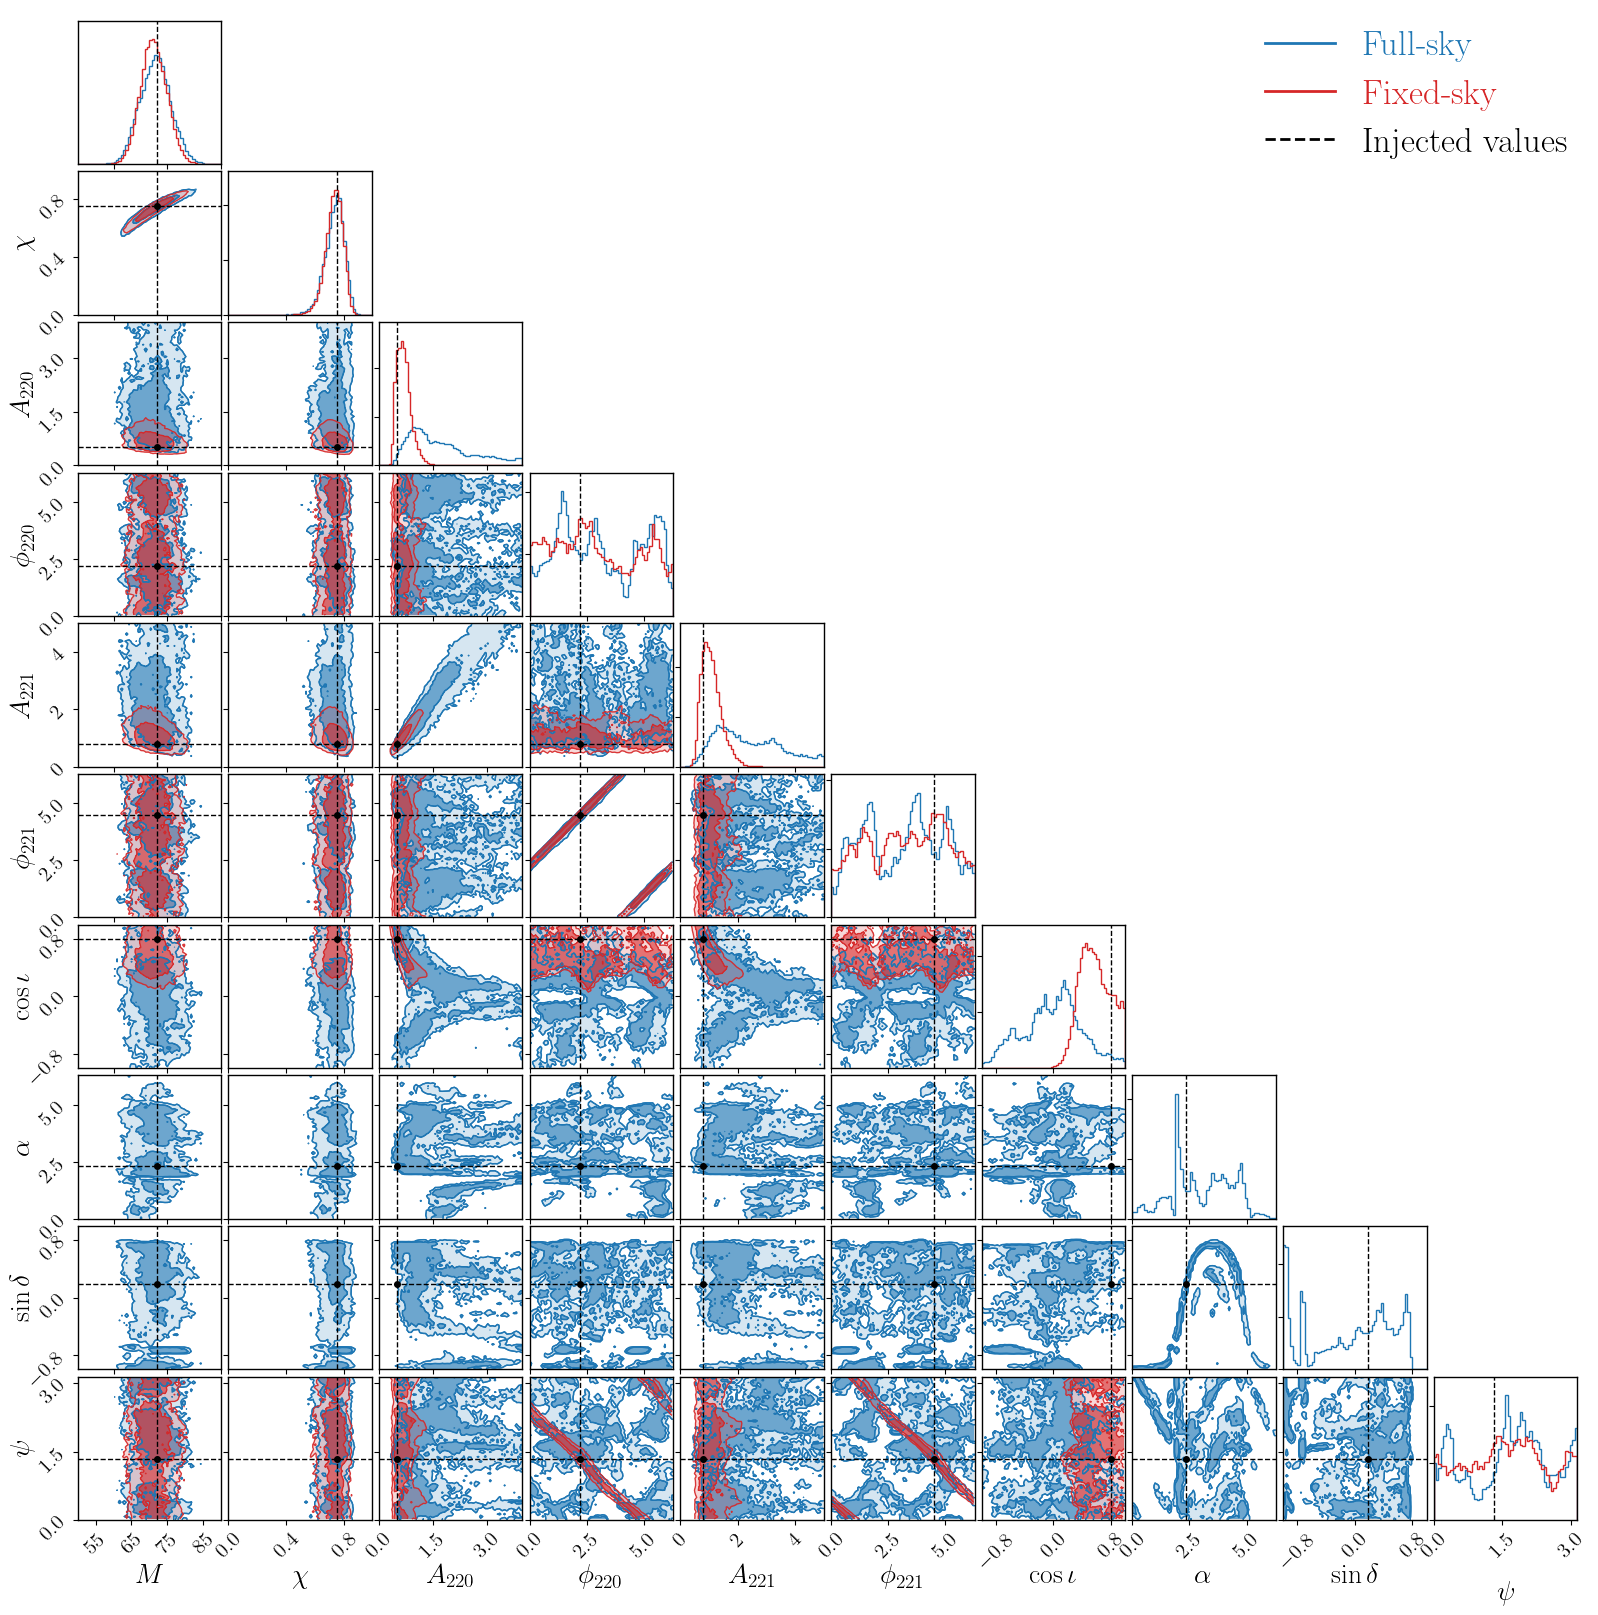

In [7]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 10,
    "axes.grid": False,
    "axes.linewidth": 1,
})

full_sky_params = [
    r'$M$', r'$\chi$', r'$A_{220}$', r'$\phi_{220}$',
    r'$A_{221}$', r'$\phi_{221}$', r'$\cos\iota$',
    r'$\alpha$', r'$\sin \delta$', r'$\psi$'
]

fixed_sky_params = [
    r'$M$', r'$\chi$', r'$A_{220}$', r'$\phi_{220}$',
    r'$A_{221}$', r'$\phi_{221}$', r'$\cos\iota$', r'$\psi$'
]

sky_params = [r'$\alpha$', r'$\sin \delta$']

bounds = {
    r'$M$': (50.0, 90.0),
    r'$\chi$': (0.0, 0.99),
    r'$A_{220}$': (0.0, 4.0),
    r'$\phi_{220}$': (0.0, 2 * onp.pi),
    r'$A_{221}$': (0.0, 5.0),
    r'$\phi_{221}$': (0.0, 2 * onp.pi),
    r'$\cos\iota$': (-1.0, 1.0),
    r'$\alpha$': (0.0, 6.28),
    r'$\sin \delta$': (-1.0, 1.0),
    r'$\psi$': (0.0, 3.14),
}

df_full_sky = pd.DataFrame(posterior_full_sky, columns=full_sky_params)
df_fixed_sky_inj = pd.DataFrame(posterior_fixed_sky_inj, columns=fixed_sky_params)

truths = onp.array([theta_GT[i] for i in range(len(full_sky_params))])
ranges = [bounds[p] for p in full_sky_params]

samples_full = df_full_sky[full_sky_params].values
samples_fixed_inj = df_fixed_sky_inj[fixed_sky_params].values

fig = corner.corner(
    samples_full,
    labels=full_sky_params,
    range=ranges,
    color="#1f77b4",
    bins=60,
    smooth=None,
    plot_datapoints=False,
    plot_density=False,
    plot_contours=True,
    fill_contours=False,
    levels=(0.683, 0.954),
    label_kwargs={"fontsize": 20},
    hist_kwargs={"linewidth": 1., "histtype": "step", "density": True},
    contour_kwargs={"linewidths": 1.},
    show_titles=False,
)

fig.set_size_inches(16, 16)

ndim = len(full_sky_params)
axes = onp.array(fig.axes).reshape((ndim, ndim))

shared_params = fixed_sky_params
shared_inds = [full_sky_params.index(p) for p in shared_params]

sky_inds = [full_sky_params.index(p) for p in sky_params]


def density_hist(x, param, bins=60):
    return onp.histogram(
        x,
        bins=bins,
        range=bounds[param],
        density=True,
    )


diag_ymax = {}

for i, p in enumerate(full_sky_params):
    ax = axes[i, i]
    ax.cla()

    ymax = 0.0

    h, edges = density_hist(df_full_sky[p].values, p)
    ymax = max(ymax, onp.nanmax(h))
    ax.stairs(h, edges, color="#1f77b4", linewidth=1.)

    if p in fixed_sky_params:
        h, edges = density_hist(df_fixed_sky_inj[p].values, p)
        ymax = max(ymax, onp.nanmax(h))
        ax.stairs(h, edges, color="#d62728", linewidth=1.)


    ax.set_xlim(bounds[p])
    ax.set_ylim(0.0, 1.15 * ymax)
    ax.set_yticks([])
    diag_ymax[p] = 1.15 * ymax


def get_levels_from_probs(H, probs=(0.954, 0.683)):
    Hflat = H.flatten()
    Hflat = Hflat[onp.isfinite(Hflat)]

    if Hflat.size == 0 or Hflat.max() <= 0:
        return None

    Hsort = onp.sort(Hflat)[::-1]
    cumsum = onp.cumsum(Hsort)
    cumsum /= cumsum[-1]

    levels = []
    for p in probs:
        levels.append(Hsort[onp.searchsorted(cumsum, p)])

    return onp.sort(levels)


def filled_contours(samples, color, param_list, inds,
                    alpha_outer=0.18, alpha_inner=0.65):
    for a, i in enumerate(inds):
        for b, j in enumerate(inds[:a]):

            x = samples[:, b]
            y = samples[:, a]

            xb = bounds[param_list[b]]
            yb = bounds[param_list[a]]

            H, xedges, yedges = onp.histogram2d(
                x,
                y,
                bins=60,
                range=[xb, yb],
                density=True,
            )

            levels = get_levels_from_probs(H, probs=(0.954, 0.683))
            if levels is None:
                continue

            vmax = onp.nanmax(H)
            if not onp.isfinite(vmax) or vmax <= levels[-1]:
                continue

            xcenters = 0.5 * (xedges[1:] + xedges[:-1])
            ycenters = 0.5 * (yedges[1:] + yedges[:-1])

            ax = axes[i, j]

            ax.contourf(
                xcenters,
                ycenters,
                H.T,
                levels=[levels[0], levels[1], vmax],
                colors=[
                    to_rgba(color, alpha_outer),
                    to_rgba(color, alpha_inner),
                ],
                zorder=1,
            )

            ax.contour(
                xcenters,
                ycenters,
                H.T,
                levels=levels,
                colors=[color],
                linewidths=1.,
                alpha=0.9,
                zorder=2,
            )


filled_contours(samples_full, "#1f77b4", full_sky_params, list(range(ndim)))
filled_contours(samples_fixed_inj, "#d62728", shared_params, shared_inds)

# Plot truths LAST so they stay on top
for i in range(ndim):
    axes[i, i].axvline(
        truths[i],
        color="black",
        linewidth=1.,
        linestyle='--',
        zorder=100,
    )

    for j in range(i):
        ax = axes[i, j]

        ax.axvline(
            truths[j],
            color="black",
            linewidth=1.,
            linestyle='--',
            zorder=100,
        )
        ax.axhline(
            truths[i],
            color="black",
            linewidth=1.,
            linestyle='--',
            zorder=100,
        )
        ax.plot(
            truths[j],
            truths[i],
            marker="o",
            color="black",
            markersize=4,
            zorder=101,
        )

i_alpha = full_sky_params.index(r'$\alpha$')
i_sindelta = full_sky_params.index(r'$\sin \delta$')


for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]

        if i < j:
            ax.set_visible(False)
            continue

        ax.set_xlim(bounds[full_sky_params[j]])

        if i == j:
            ax.set_ylim(0.0, diag_ymax[full_sky_params[i]])
            ax.set_yticks([])
        else:
            ax.set_ylim(bounds[full_sky_params[i]])

        if i != ndim - 1:
            ax.tick_params(axis="x", labelbottom=False)
            ax.set_xlabel("")

        if j != 0:
            ax.tick_params(axis="y", labelleft=False)
            ax.set_ylabel("")

        ax.xaxis.set_major_locator(MaxNLocator(3))
        ax.yaxis.set_major_locator(MaxNLocator(3))
        ax.tick_params(labelsize=15)
        ax.grid(False)

axes[-1, -1].set_xlabel(r'$\psi$', fontsize=20, labelpad=24)
axes[-1, -1].xaxis.set_label_coords(0.5, -0.42)

for tick in axes[-1, -1].get_xticklabels():
    tick.set_rotation(45)

axes[0, 0].set_yticks([])
axes[0, 0].set_ylabel("")
axes[0, 0].tick_params(axis="y", left=False, labelleft=False)

# manual adjustments to make sure tick labels do not overlap
axes[-1,0].set_xticks([55.0, 65.0, 75.0, 85.0])
# axes[-1,4].set_xticks([0.0, 0.5, 1.0])
# axes[-1,2].set_xticks([0.0, 1.0, 2.0])
# axes[4,0].set_yticks([0.0, 0.5, 1.0])
# axes[2,0].set_yticks([0.0, 1.0, 2.0])

legend_handles = [
    mlines.Line2D([], [], color="#1f77b4", label="Full-sky", linewidth=2),
    mlines.Line2D([], [], color="#d62728", label="Fixed-sky", linewidth=2),
    mlines.Line2D([], [], color="#000000", label="Injected values", linewidth=2, linestyle='--'),
]

fig.legend(
    handles=legend_handles,
    labelcolor='linecolor',
    fontsize=25,
    loc="upper right",
    frameon=False,
)
plt.savefig('./plots/noiseless-sim-221-220.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Mode amplitude ratio for Full-sky and Fixed-sky 

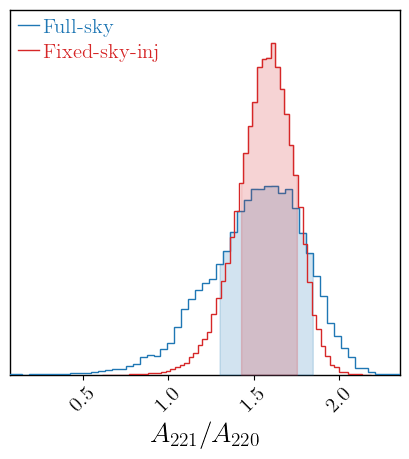

In [7]:
df_full_sky = pd.DataFrame(posterior_full_sky[:,4]/posterior_full_sky[:,2], columns=[r'$A_{221}/A_{220}$'])
df_fixed_sky_inj = pd.DataFrame(posterior_fixed_sky_inj[:,4]/posterior_fixed_sky_inj[:,2], columns=[r'$A_{221}/A_{220}$'])

truths = {r'$A_{221}/A_{220}$': theta_GT[4]/theta_GT[2]}


c = ChainConsumer()
c.add_chain(Chain(samples=df_full_sky, color='#1f77b4', name="Full-sky"))
c.add_chain(Chain(samples=df_fixed_sky_inj, color='#d62728', name="Fixed-sky-inj"))
c.set_override(ChainConfig(sigmas=[0, 1, 2], bins=60, smooth=0, bar_shade=1))
c.set_plot_config(
    PlotConfig(
        # flip=True,
        # labels=ns_parameters,
        usetex=1,
        serif=1,
        label_font_size=20,
        tick_font_size=15,
        contour_label_font_size=24,
        legend_kwargs={'fontsize': 15, 'loc': 'upper left'}
    )
)
fig = c.plotter.plot()


plt.savefig('./plots/noiseless-sim-221-220-amp-ratio.pdf', dpi=300, bbox_inches='tight')
plt.show()